In [80]:
import torch

CSV_PATH = "datasets/real_and_fake.csv"

BASE_DIR = "datasets"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [81]:
print(DEVICE)

cuda


In [82]:
import os

FRAME_DIR = "processed_frames"

REAL_FRAME_DIR = os.path.join(FRAME_DIR, "real")
ATTACK_FRAME_DIR = os.path.join(FRAME_DIR, "attack")

os.makedirs(REAL_FRAME_DIR, exist_ok=True)
os.makedirs(ATTACK_FRAME_DIR, exist_ok=True)

In [83]:
import pandas as pd
df = pd.read_csv(CSV_PATH, delimiter=",")
print(df.head())

                     file    type  split
0  train/real_video/0.mp4    real  train
1      train/attack/0.mp4  attack  train
2  train/real_video/1.mp4    real  train
3      train/attack/1.mp4  attack  train
4  train/real_video/2.mp4    real  train


In [84]:
import cv2

def extract_frames(video_path, output_dir, prefix, every_n_frame=10):
    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_count % every_n_frame == 0:
            filename = f"{prefix}_{saved_count}.jpg"
            save_path = os.path.join(
                output_dir,
                filename
            )
            cv2.imwrite(save_path, frame)
            saved_count += 1
        frame_count += 1
    cap.release()

In [85]:
from tqdm import tqdm

df_train = df[df["split"] == "train"]

print("[INFO] Extracting frames...")
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    video_rel_path = row["file"]
    label = row["type"]

    video_path = os.path.join(BASE_DIR, video_rel_path)
    if label == "real":
        output_dir = REAL_FRAME_DIR
    else:
        output_dir = ATTACK_FRAME_DIR

    extract_frames(
        video_path=video_path,
        output_dir=output_dir,
        prefix=f"{label}_{idx}"
    )

print("[INFO] Frame extraction complete.")

[INFO] Extracting frames...


100%|████████████████████████████████████████████████████████████████████████████████| 110/110 [03:18<00:00,  1.80s/it]

[INFO] Frame extraction complete.


In [86]:
import torch 
from PIL import Image
from torch.utils.data import Dataset

class LivenessDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [87]:
import os

image_paths = []
labels = []

# REAL
for img in os.listdir(REAL_FRAME_DIR):
    image_paths.append(os.path.join(REAL_FRAME_DIR, img))
    labels.append(1)

# ATTACK
for img in os.listdir(ATTACK_FRAME_DIR):
    image_paths.append(os.path.join(ATTACK_FRAME_DIR, img))
    labels.append(0)

print(f"[INFO] Total images: {len(image_paths)}")

[INFO] Total images: 5725


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [89]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [90]:
from torch.utils.data import DataLoader

train_dataset = LivenessDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = LivenessDataset(
    X_val,
    y_val,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [91]:
import torch.nn as nn

class CDCBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv(x)
        # central difference approximation
        center = out.mean(dim=(2,3), keepdim=True)

        out = out - center
        out = self.bn(out)
        out = self.relu(out)

        return out

In [92]:
class SimpleCDCN(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = CDCBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.layer2 = CDCBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.layer3 = CDCBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(128, 1)

    def forward(self, x):

        x = self.pool1(self.layer1(x))
        x = self.pool2(self.layer2(x))
        x = self.pool3(self.layer3(x))

        x = self.global_pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [93]:
model = SimpleCDCN().to(DEVICE)

In [94]:
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [95]:
train_accuracies = []
val_accuracies = []

train_losses = []
val_losses = []

print("[INFO] Start training...")
for epoch in range(EPOCHS):

    # =====================================================
    # TRAINING
    # =====================================================

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        accuracy = 100 * correct / total

        loop.set_description(
            f"Epoch [{epoch+1}/{EPOCHS}]"
        )

        loop.set_postfix(
            loss=loss.item(),
            acc=accuracy
        )

    # FINAL TRAIN METRIC
    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # SAVE HISTORY
    train_accuracies.append(train_acc)
    train_losses.append(train_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    val_correct = 0
    val_total = 0

    val_running_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images).squeeze()

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss = val_running_loss / len(test_loader)

    # SAVE HISTORY
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

    # =====================================================
    # PRINT RESULT
    # =====================================================

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.2f}%"
    )



[INFO] Start training...


Epoch [1/10]: 100%|████████████████████████████████████████████| 144/144 [01:11<00:00,  2.02it/s, acc=68.5, loss=0.772]



Epoch [1/10] | Train Loss: 0.6169 | Train Acc: 68.54% | Val Loss: 0.3032 | Val Acc: 70.74%


Epoch [2/10]: 100%|████████████████████████████████████████████| 144/144 [01:04<00:00,  2.24it/s, acc=74.6, loss=0.576]



Epoch [2/10] | Train Loss: 0.5674 | Train Acc: 74.63% | Val Loss: 0.2846 | Val Acc: 76.07%


...


Epoch [8/10] | Train Loss: 0.4273 | Train Acc: 84.15% | Val Loss: 0.2057 | Val Acc: 87.77%


Epoch [9/10]: 100%|████████████████████████████████████████████| 144/144 [01:03<00:00,  2.26it/s, acc=84.5, loss=0.312]



Epoch [9/10] | Train Loss: 0.4102 | Train Acc: 84.48% | Val Loss: 0.1966 | Val Acc: 89.34%


Epoch [10/10]: 100%|███████████████████████████████████████████| 144/144 [01:03<00:00,  2.27it/s, acc=85.6, loss=0.752]



Epoch [10/10] | Train Loss: 0.3976 | Train Acc: 85.61% | Val Loss: 0.1880 | Val Acc: 89.26%


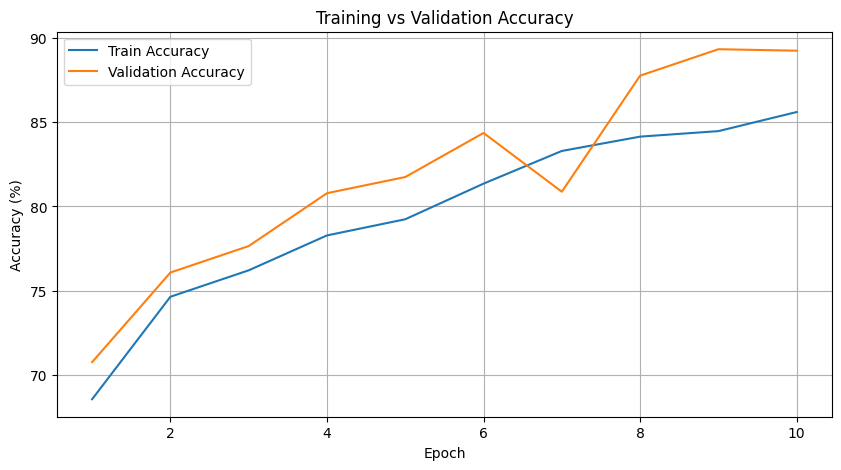

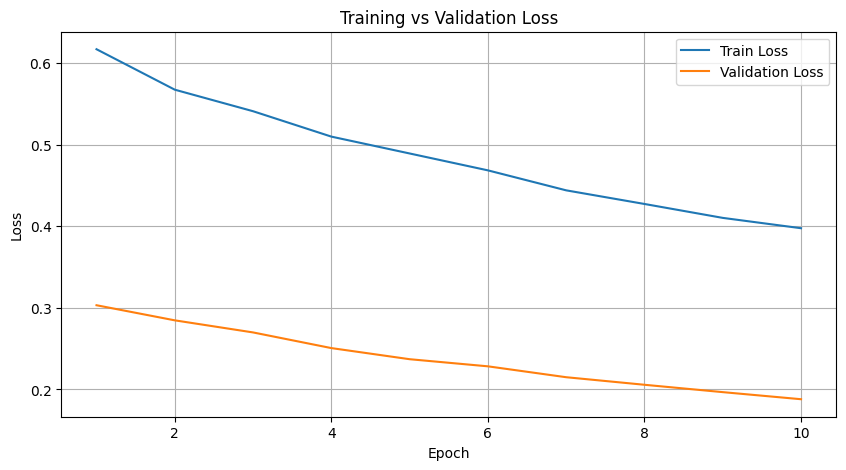

In [96]:
import matplotlib.pyplot as plt

# =========================================================
# PLOT ACCURACY
# =========================================================

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# PLOT LOSS
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [97]:
test_df = df[df["split"] == "test"]

In [98]:
import os

FRAME_DIR = "processed_test_frames"

REAL_FRAME_DIR = os.path.join(FRAME_DIR, "real")
ATTACK_FRAME_DIR = os.path.join(FRAME_DIR, "attack")

os.makedirs(REAL_FRAME_DIR, exist_ok=True)
os.makedirs(ATTACK_FRAME_DIR, exist_ok=True)

In [99]:
from tqdm import tqdm

df_test = df[df["split"] == "test"]

print("[INFO] Extracting frames for test...")
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    video_rel_path = row["file"]
    label = row["type"]

    video_path = os.path.join(BASE_DIR, video_rel_path)
    if label == "real":
        output_dir = REAL_FRAME_DIR
    else:
        output_dir = ATTACK_FRAME_DIR

    extract_frames(
        video_path=video_path,
        output_dir=output_dir,
        prefix=f"{label}_{idx}"
    )

print("[INFO] Frame extraction complete.")

[INFO] Extracting frames for test...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [01:59<00:00,  2.38s/it]

[INFO] Frame extraction complete.


In [100]:
import os

image_paths = []
labels = []

# REAL
for img in os.listdir(REAL_FRAME_DIR):
    image_paths.append(os.path.join(REAL_FRAME_DIR, img))
    labels.append(1)

# ATTACK
for img in os.listdir(ATTACK_FRAME_DIR):
    image_paths.append(os.path.join(ATTACK_FRAME_DIR, img))
    labels.append(0)

print(f"[INFO] Total images: {len(image_paths)}")

[INFO] Total images: 2148


In [101]:
from torch.utils.data import DataLoader

test_dataset = LivenessDataset(
    image_paths,
    labels,
    transform=test_transform
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [102]:
# =========================================================
# TESTING / EVALUATION
# =========================================================

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images).squeeze()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# =========================================================
# FINAL ACCURACY
# =========================================================

test_accuracy = 100 * correct / total

print(f"\nTest Accuracy: {test_accuracy:.2f}%")

100%|██████████████████████████████████████████████████████████████████████████████████| 68/68 [00:34<00:00,  1.97it/s]


Test Accuracy: 85.10%
